# Tripcolor plots

first try plotting Icon original grid

In [1]:
%matplotlib inline

# system libs
import os, sys, glob
import datetime

# array operators and netcdf datasets
import numpy as np
import xarray as xr
xr.set_options(keep_attrs=True)

# plotting
import pylab as plt
import seaborn as sns
sns.set_context('talk')

import matplotlib.dates as mdates
myFmt = mdates.DateFormatter('%H:%M')

# to have tools to format time
sys.path.append( '/work/bb1224/2024_MS-COURSE/tools/analysis' )
from tools import convert_timevec

# drawing onto a map
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

import warnings
warnings.simplefilter("ignore")

## Open datasets, cut domain and format time

In [2]:
# Path
# Irenes experiment:
#sim_path = '/work/bb1376/user/irene/icon-build/experiments/cesar1-20240806-exp008'
sim_path = '/work/bb1376/user/irene/icon-build/experiments/cesar2-20240928-exp001'
#sim_path = '/work/bb1376/user/irene/icon-build/experiments/cesar3-20241110-exp001'
# onw experiment without --enable-openmp
#sim_path = '/work/bb1376/user/daniel/icon-build/experiments/cesar1-20240806-exp008'
#sim_path = '/work/bb1376/user/daniel/icon-build/experiments/cesar2-20240928-exp001'
#sim_path = '/work/bb1376/user/daniel/icon-build/experiments/cesar3-20241110-exp001'

sim_path = '/work/bb1376/user/daniel/icon-build/experiments/cesar2-20240928-exp010'


In [3]:
#date= 20240806
date= 20240928
#date= 20241110

# ICON simulations for 3 nests:
# 2D variables
#ds_2dicon1 = xr.open_mfdataset(f'{sim_path}/2d_*_DOM01_ML_20240806T????00Z_regrid1km.nc')
#ds_2dicon1 = xr.open_mfdataset(f'{sim_path}/2d_*_DOM01_ML_{date}T????00Z.nc')
#ds_2dicon2 = xr.open_mfdataset(f'{sim_path}/2d_*_DOM02_ML_{date}T????00Z.nc')
#ds_2dicon3 = xr.open_mfdataset(f'{sim_path}/2d_*_DOM03_ML_{date}T????00Z.nc')

# 3D variables
#ds_3dicon1 = xr.open_mfdataset(f'{sim_path}/3d_full_base_DOM01_HL_{date}T????00Z.nc')
#ds_3dicon2 = xr.open_mfdataset(f'{sim_path}/3d_full_base_DOM02_HL_{date}T????00Z.nc')
#ds_3dicon3 = xr.open_mfdataset(f'{sim_path}/3d_full_base_DOM03_HL_{date}T????00Z.nc')


In [4]:

#radiation varibles.
ds_2dicon1rad = xr.open_mfdataset(f'{sim_path}/2d_rad_DOM01_ML_{date}T????00Z.nc')
ds_2dicon2rad = xr.open_mfdataset(f'{sim_path}/2d_rad_DOM02_ML_{date}T????00Z.nc')
ds_2dicon3rad = xr.open_mfdataset(f'{sim_path}/2d_rad_DOM03_ML_{date}T????00Z.nc')

In [5]:
# Define dictionaries to store datasets
#datasets2d = {
#    "exp001 icon d1": ds_2dicon1,
#    "exp001 icon d2": ds_2dicon2,
#    "exp001 icon d3": ds_2dicon3,
#}

datasets2drad = {
    "exp001 icon d1 rad": ds_2dicon1rad,
    "exp001 icon d2 rad": ds_2dicon2rad,
    "exp001 icon d3 rad": ds_2dicon3rad,
}


#datasets3d = {
#    "exp001 icon d1": ds_3dicon1,
#    "exp001 icon d2": ds_3dicon2,
#    "exp001 icon d3": ds_3dicon3,
#}

In [6]:
# Define Lindenberg coordinates:
lon_lind, lat_lind = 14.11845, 52.20967

# Define the spatial range over Lindenberg:
lat_min, lat_max = 51.85, 52.55    
lon_min, lon_max = 13.65, 14.55 

'''
# Apply spatial selection to all datasets
for datasets in [datasets2d, datasets3d]:
    for name, ds in datasets.items():
        datasets[name] = ds.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
'''

'\n# Apply spatial selection to all datasets\nfor datasets in [datasets2d, datasets3d]:\n    for name, ds in datasets.items():\n        datasets[name] = ds.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))\n'

In [7]:
# Format time 
#for name, ds in datasets2d.items():
#    ds['time'] = convert_timevec(ds.time.data)
for name, ds in datasets2drad.items():
    ds['time'] = convert_timevec(ds.time.data)
#for name, ds in datasets3d.items():
#    ds['time'] = convert_timevec(ds.time.data)

## Analysis


In [8]:
ds_2dicon1rad

<xarray.Dataset>
Dimensions:   (time: 7, ncells: 142720)
Coordinates:
  * time      (time) datetime64[ns] 2024-09-28T12:00:00 ... 2024-09-28T18:00:00
Dimensions without coordinates: ncells
Data variables:
    sob_s     (time, ncells) float32 dask.array<chunksize=(1, 142720), meta=np.ndarray>
    sobclr_s  (time, ncells) float32 dask.array<chunksize=(1, 142720), meta=np.ndarray>
    thbclr_s  (time, ncells) float32 dask.array<chunksize=(1, 142720), meta=np.ndarray>
    sodifd_s  (time, ncells) float32 dask.array<chunksize=(1, 142720), meta=np.ndarray>
    sou_s     (time, ncells) float32 dask.array<chunksize=(1, 142720), meta=np.ndarray>
    thb_s     (time, ncells) float32 dask.array<chunksize=(1, 142720), meta=np.ndarray>
    thu_s     (time, ncells) float32 dask.array<chunksize=(1, 142720), meta=np.ndarray>
    sob_t     (time, ncells) float32 dask.array<chunksize=(1, 142720), meta=np.ndarray>
    sod_t     (time, ncells) float32 dask.array<chunksize=(1, 142720), meta=np.ndarray>
    thb_t     (time, ncells) float32 dask.array<chunksize=(1, 142720), meta=np.ndarray>
Attributes:
    CDI:                  Climate Data Interface version 2.4.0 (https://mpime...
    Conventions:          CF-1.6
    number_of_grid_used:  99
    uuidOfHGrid:          7fad9f84-2562-8608-875c-071c55c029c0
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    title:                ICON simulation
    source:               version: 2024.10; revision: icon-2024.10-public-0-g...
    history:              /home/b/b383413/workspace/icon-build/bin/icon at 20...
    references:           see MPIM/DWD publications
    comment:              Daniel Kloster (b383413) on l10114 (Linux 4.18.0-51...

### tripcolorplots

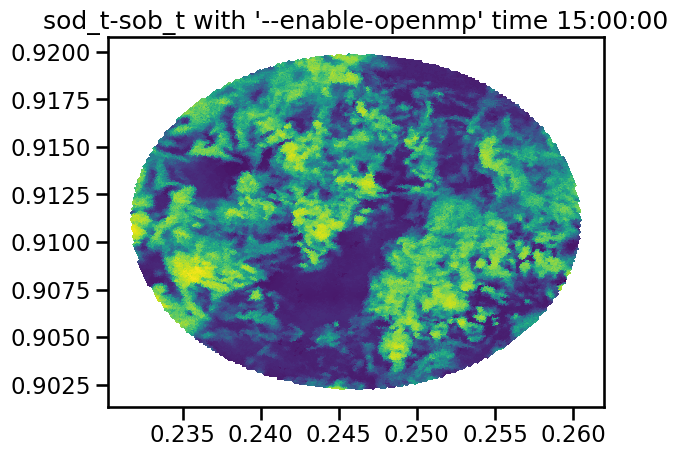

In [9]:
import matplotlib.tri as tri

dom = "3" 
time= "15:00:00"

grid = xr.open_dataset( f'{sim_path}/domain{dom}_DOM0{dom}.nc' )

#rad = ds_2dicon3rad.sel(time='2024-08-06T15:00:00') # select time
rad = eval(f"ds_2dicon{dom}rad").sel(time=f'{date}T{time}')


voc = grid['vertex_of_cell'].T - 1  # ICON nutzt 1-basierte Indizierung
tri = plt.matplotlib.tri.Triangulation( grid['vlon'], grid['vlat'], triangles=voc)


diff = (rad['sod_t'] - rad['sob_t'])

plt.tripcolor(tri, diff)
plt.title(f"sod_t-sob_t with '--enable-openmp' time {time}")
plt.show()
